In [16]:
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import scipy.signal as signal
import os
import sys
import time
sys.path.append(os.path.abspath('..'))
from package import load_rirs, select_latest_rir
from package.utils import music_wideband, create_micsigs

base_path = '..'
path_to_rirs = os.path.join(base_path, 'rirs')
rir_file = select_latest_rir(path_to_rirs)
acoustic_scenario = load_rirs(rir_file)

# Het spraakvermogen wordt uitsluitend berekend over de actieve spraaksegmenten  
# zodat stiltes het gemiddelde niet omlaag trekken. 
def create_micsigs_modified(acoustic_scenario, speech_filenames, noise_filenames, duration):
    fs_rir = acoustic_scenario.fs
    if fs_rir != 44100:
        raise ValueError(f"Fout: Sampling frequency moet 44.1 kHz zijn, maar is {fs_rir} Hz.")
    num_mics = len(acoustic_scenario.RIRs_audio[0])
    num_samples = int(duration * fs_rir)
    
    speech_component = np.zeros((num_samples, num_mics))
    noise_component = np.zeros((num_samples, num_mics))

    for src_idx, filename in enumerate(speech_filenames):
        audio, fs_src = sf.read(filename)
        if fs_src != fs_rir:
            new_len = int(len(audio) * fs_rir / fs_src)
            audio = signal.resample(audio, new_len)
        
        for mic_idx in range(num_mics):
            rir = acoustic_scenario.RIRs_audio[:, mic_idx, src_idx]
            filtered = signal.fftconvolve(audio, rir, mode='full')
            
      
            
            L = min(len(filtered), num_samples)
            speech_component[:L, mic_idx] += filtered[:L]

# RUIS 

    if noise_filenames and len(noise_filenames) > 0 and acoustic_scenario.RIRs_noise is not None:
        for src_idx, filename in enumerate(noise_filenames):
            if not filename: continue
          
            audio, fs_src = sf.read(filename)
            
            if fs_src != fs_rir:
                audio = signal.resample(audio, int(len(audio) * fs_rir / fs_src))
                
            for mic_idx in range(num_mics):
  
                rir = acoustic_scenario.RIRs_noise[:, mic_idx, src_idx]
                filtered = signal.fftconvolve(audio, rir, mode='full')
                
                L = min(len(filtered), num_samples)
                noise_component[:L, mic_idx] += filtered[:L]
    else:
        print("INFO: Ruis-verwerking overgeslagen (geen bestanden of geen ruis-RIRs gevonden).")

    speech_mic1 = speech_component[:, 0]
    vad = np.abs(speech_mic1) > np.std(speech_mic1) * 1e-3
    active_speech = speech_mic1[vad]
    Ps = np.var(active_speech) if len(active_speech) > 0 else 0
    Pn_target = 0.1 * Ps
    white_noise = np.random.normal(0, np.sqrt(Pn_target), (num_samples, num_mics))
       
    noise_component += white_noise
    Pn_actual = np.var(noise_component[:, 0])
    
    
    # snr_mic1 = 10 * np.log10(Ps / Pn_actual)
    # print(f"SIR in de eerste microfoon: {snr_mic1:.2f} dB")
    

    # mic = speech_component + noise_component

    
    # return mic, speech_component, noise_component, snr_mic1, vad
    # --- NIEUWE CODE ---
    # Bereken de echte SIR over het héle signaal (exact zoals compute_sir)
    P_speech_total = np.var(speech_component[:, 0])
    P_noise_total = np.var(noise_component[:, 0])
    sir_mic1 = 10 * np.log10(P_speech_total / (P_noise_total + 1e-10)) # 1e-10 voorkomt deling door nul
    
    print(f"Input SIR (Mic 1): {sir_mic1:.2f} dB")
    
    mic = speech_component + noise_component
    
    return mic, speech_component, noise_component, sir_mic1, vad

In [17]:
def compute_sir(y, x1, x2, groundTruth):
    """
    Compute the signal-to-interference ratio for two sources (one target source
    and one interfering source). The script takes into account possible
    switches between which source is the target and which one is the
    interference. The script assumes there is access to each source's
    contribution in the beamformer output.

    Parameters
    ----------
    -y : [N x 1] np.ndarray[float]
        Actual beamformer output signal (`N` is the number of samples).
    -x1 : [N x 1] np.ndarray[float]
        Beamformer output attributed to source 1.
    -x2 : [N x 1] np.ndarray[float]
        Beamformer output attributed to source 2.
    -groundTruth : [N x 1] np.ndarray[int (0 or 1) or float (0. or 1.)]
        Array indicating, for each sample,
        which source is the target: 1=x1, 0=x2.

    Returns
    -------
    -sir : 
    """
    # Sanity check (check whether `y = x1 + x2` based on RMSE of residual)
    if np.sqrt(np.sum((y - x1 - x2) ** 2)) / np.sqrt(np.sum(y ** 2)) > 0.01:
        print('/!\ Something is wrong, `y` should be the sum of `x1` and `x2`.')  
        print('SIR can not be computed -- Returning NaN.')  
        sir = np.nan
    # Input check
    elif np.sum(groundTruth) + np.sum(1 - groundTruth) != len(groundTruth):
        print('/!\ `groundTruth` vector is not binary.')
        print('SIR can not be computed')  
        sir = np.nan
    else:
        sir = 10 * np.log10(
            np.var(x1 * groundTruth + x2 * (1 - groundTruth)) /\
                np.var(x2 * groundTruth + x1 * (1 - groundTruth))
        )

    return sir

<>:27: SyntaxWarning: invalid escape sequence '\ '
<>:32: SyntaxWarning: invalid escape sequence '\ '
<>:27: SyntaxWarning: invalid escape sequence '\ '
<>:32: SyntaxWarning: invalid escape sequence '\ '
C:\Users\piete\AppData\Local\Temp\ipykernel_52676\1998567044.py:27: SyntaxWarning: invalid escape sequence '\ '
  print('/!\ Something is wrong, `y` should be the sum of `x1` and `x2`.')
C:\Users\piete\AppData\Local\Temp\ipykernel_52676\1998567044.py:32: SyntaxWarning: invalid escape sequence '\ '
  print('/!\ `groundTruth` vector is not binary.')


In [18]:
def das_bf(scenario, speech_paths, noise_paths=None, duration=10.0):
    if noise_paths is None:
        noise_paths = []

    mic, speech, noise, snr_in, vad = create_micsigs_modified(scenario, speech_paths, noise_paths, duration)

    num_audio = scenario.audioPos.shape[0] if scenario.audioPos is not None else 0
    num_noise = scenario.noisePos.shape[0] if (hasattr(scenario, 'noisePos') and scenario.noisePos is not None) else 0
    Q = num_audio + num_noise
    
    # DOA Schatting
    angles, ps_ind_db, spectrum_geom_db, est_doas = music_wideband(mic, scenario.fs, scenario)

    # Kies de DOA die het dichtst bij 90 graden ligt (broadside direction)
    target_doa = est_doas[np.argmin(np.abs(est_doas - 90.0))]
    print(f"[DAS BF] Target bron gedetecteerd door MUSIC op: {target_doa:.1f}°")
   
    target_rad = np.radians(target_doa)
    c = 343.0
    mics_centered = scenario.micPos - np.mean(scenario.micPos, axis=0)
    taus = (mics_centered[:, 0] * np.sin(target_rad) + mics_centered[:, 1] * np.cos(target_rad)) / c

# Functie om signalen uit te lijnen in het frequentiedomein
#Sub-sample precisie via de Fourier Shift Theorem:
# In plaats van signalen simpelweg een geheel aantal samples (indexen) op te schuiven, 
# passen we de vertraging toe als een faseverschuiving in het frequentiedomein. 
# Hierdoor kunnen we exact "tussen de samples" vertragen, wat afrondingsfouten 
# en faseproblemen voorkomt en resulteert in een veel zuiverdere beamformer.
    def apply_das(signals, delays, fs):
        M = signals.shape[1]
        N = signals.shape[0]
        out_sum = np.zeros(N)
        out_aligned = np.zeros((N, M))
        f = np.fft.rfftfreq(N, 1/fs)
        for m in range(M):
            Sig = np.fft.rfft(signals[:, m]) #reeks van n reele getallen naar complexe getallen-> elk complex getal amplitude en fase van specifieke freq
            Sig_aligned = Sig * np.exp(1j * 2 * np.pi * f * delays[m]) #hoge toon grotere faseverschuiving dan lagere
            t_aligned = np.fft.irfft(Sig_aligned, n=N) #evenveel samples als waarmee je begon
            out_aligned[:, m] = t_aligned
            out_sum += t_aligned #versterken elkaar nu bij optellen
        return out_sum / M, out_aligned

    speechDAS, speech_aligned = apply_das(speech, taus, scenario.fs)
    noiseDAS, noise_aligned = apply_das(noise, taus, scenario.fs)
    
    DASout = speechDAS + noiseDAS
    aligned_mic = speech_aligned + noise_aligned  

    # P_speech_das = np.var(speechDAS[vad == 1])
    # P_noise_das = np.var(noiseDAS)
    # if P_noise_das < 1e-10: P_noise_das = 1e-10
    # SNRoutDAS = 10 * np.log10(P_speech_das / P_noise_das)

    # --- NIEUWE CODE ---
    # 1. Maak een groundTruth array vol met 1'en (lengte van het signaal). 
    # Dit vertelt de functie dat 'speechDAS' overal de target is.
    groundTruth = np.ones(len(DASout), dtype=int)
    
    # 2. Roep de compute_sir functie aan in plaats van de variantie-schatting.
    SNRoutDAS = compute_sir(y=DASout, x1=speechDAS, x2=noiseDAS, groundTruth=groundTruth)

    print(f"[DAS BF] Output SIR: {SNRoutDAS:.2f} dB")
    
    return DASout, speechDAS, noiseDAS, SNRoutDAS, mic, aligned_mic, speech_aligned, noise_aligned, vad, snr_in

In [19]:
def gsc_td(scenario, speech_paths, noise_paths=None, duration=10.0):
    # 1. Ontvang de extra variabelen
    DASout, speechDAS, noiseDAS, SNRoutDAS, mic, aligned_mic, speech_aligned, noise_aligned, vad, snr_in = das_bf(
        scenario, speech_paths, noise_paths, duration=duration
    )

    N_samples, M_mics = aligned_mic.shape

    # Blocking Matrix B (Griffiths-Jim)
    B = np.zeros((M_mics - 1, M_mics))
    for i in range(M_mics - 1):
        B[i, 0] = 1
        B[i, i + 1] = -1
        
    noise_refs = (B @ aligned_mic.T).T  
    
    # NIEUW: Bereken de ruisreferenties voor spraak en ruis apart
    noise_refs_speech = (B @ speech_aligned.T).T
    noise_refs_noise = (B @ noise_aligned.T).T

    L = 1024
    mu = 0.15
    delta = L // 2

    # Pre-processing signalen (Mix, Target, Interference)
    target_ref = np.pad(DASout, (delta, 0))[:N_samples] 
    target_ref_speech = np.pad(speechDAS, (delta, 0))[:N_samples] # NIEUW
    target_ref_noise = np.pad(noiseDAS, (delta, 0))[:N_samples]   # NIEUW
    
    W = np.zeros((L, M_mics - 1)) 
    
    # Output arrays
    GSCout = np.zeros(N_samples)
    GSCout_speech = np.zeros(N_samples) # NIEUW
    GSCout_noise = np.zeros(N_samples)  # NIEUW
    
    padded_noise = np.pad(noise_refs, ((L-1, 0), (0, 0))) 
    padded_noise_speech = np.pad(noise_refs_speech, ((L-1, 0), (0, 0))) # NIEUW
    padded_noise_noise = np.pad(noise_refs_noise, ((L-1, 0), (0, 0)))   # NIEUW

    eps = 1e-8 
    vad_delayed = np.pad(vad, (delta, 0))[:N_samples] 

    for n in range(N_samples):
        # 1. Berekening voor de Mix (blijft hetzelfde)
        X_slice = padded_noise[n : n+L] 
        y_n = np.sum(W * X_slice) 
        e_n = target_ref[n] - y_n 
        GSCout[n] = e_n
        
        # 2. NIEUW: Pas dezelfde W-gewichten toe op de gescheiden signalen
        X_slice_speech = padded_noise_speech[n : n+L]
        GSCout_speech[n] = target_ref_speech[n] - np.sum(W * X_slice_speech)
        
        X_slice_noise = padded_noise_noise[n : n+L]
        GSCout_noise[n] = target_ref_noise[n] - np.sum(W * X_slice_noise)
        
        # 3. Filter updatet alleen op basis van de MIX als er geen spraak is
        if vad_delayed[n] == 0:
            power = np.sum(X_slice**2)
            W += (mu * e_n / (power + eps)) * X_slice

    # Pn_gsc = np.var(GSCout[vad_delayed == 0])
    # Psn_gsc = np.var(GSCout[vad_delayed == 1])
    # Ps_gsc = Psn_gsc - Pn_gsc
    # if Ps_gsc <= 0: Ps_gsc = 1e-10 
    # if Pn_gsc <= 0: Pn_gsc = 1e-10
    
    #SNRoutGSC = 10 * np.log10(Ps_gsc / Pn_gsc)
    # --- NIEUWE BEREKENING ---
    groundTruth = np.ones(len(GSCout), dtype=int)
    SNRoutGSC = compute_sir(y=GSCout, x1=GSCout_speech, x2=GSCout_noise, groundTruth=groundTruth)
    print(f"[GSC] Output SIR: {SNRoutGSC:.2f} dB (Netto Verbetering vs Mic1: {SNRoutGSC - snr_in:.2f} dB)")


    # Plotting
    t = np.arange(N_samples) / scenario.fs
    GSCout_plot = np.pad(GSCout[delta:], (0, delta)) #verwijder kunstmatige stilte en voeg erna aan einde nullen toe zodat lijst even lang blijft
    
    plt.figure(figsize=(14, 7))
    plt.plot(t, mic[:, 0], color='gray', alpha=0.5, label=f'Mic 1 (Input SIR: {snr_in:.1f} dB)')
    plt.plot(t, DASout, color='dodgerblue', alpha=0.6, label=f'DAS Beamformer (SIR: {SNRoutDAS:.1f} dB)')
    plt.plot(t, GSCout_plot, color='green', alpha=0.9, linewidth=1.2, label=f'GSC Output (SIR: {SNRoutGSC:.1f} dB)')
    
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title("Comparison: Original vs. DAS-BF vs. GSC")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

    return GSCout, SNRoutGSC, mic, DASout, GSCout_plot, noise_refs



Input SIR (Mic 1): 2.94 dB
Q = 2
[DAS BF] Target bron gedetecteerd door MUSIC op: 129.7°
[DAS BF] Output SIR: 6.83 dB
[GSC] Output SIR: 12.88 dB (Netto Verbetering vs Mic1: 9.94 dB)


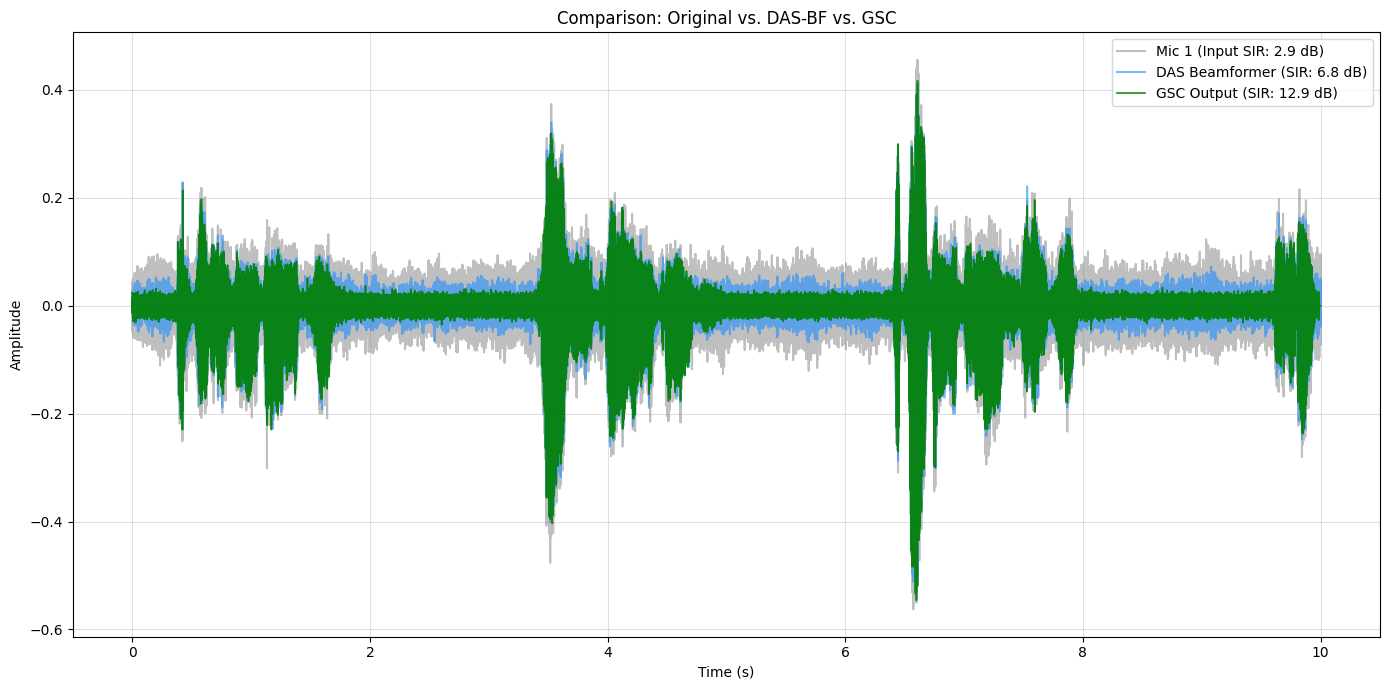

In [32]:
rirs_folder = os.path.join(base_path, 'rirs')
latest_rir = select_latest_rir(path_to_rirs)
scenario = load_rirs(latest_rir)

alle_spraak_bestanden = [
    os.path.join(base_path, "sound_files", "speech1.wav"),
    #os.path.join(base_path, "sound_files", "speech2.wav")
]


ruis_pad = os.path.join(base_path, "sound_files", "Babble_noise1.wav")
alle_ruis_bestanden = [ruis_pad]

GSCout, SNRoutGSC, mic, DASout, GSCout_plot, noise_refs = gsc_td(scenario, alle_spraak_bestanden, alle_ruis_bestanden, duration=10.0)



In [ ]:
def gsc_td_shadow(mic_mix, t_comp, i_comp, target_doa, fs, scenario, mu=0.1):
    N_samples, M_mics = mic_mix.shape
    c = 343.0
    
    # 1. Bereken vertragingen voor de DAS Beamformer
    rad = np.radians(target_doa)
    mics_centered = scenario.micPos - np.mean(scenario.micPos, axis=0)
    taus = (mics_centered[:, 0] * np.sin(rad) + mics_centered[:, 1] * np.cos(rad)) / c
    
    # Lijn signalen uit via FFT (Fractional Delay)
    def align_signals(sigs):
        aligned = np.zeros_like(sigs)
        f = np.fft.rfftfreq(N_samples, 1/fs)
        for m in range(M_mics):
            Sig = np.fft.rfft(sigs[:, m])
            Sig_aligned = Sig * np.exp(1j * 2 * np.pi * f * taus[m])
            aligned[:, m] = np.fft.irfft(Sig_aligned, n=N_samples)
        return aligned

    aligned_mix = align_signals(mic_mix)
    aligned_tar = align_signals(t_comp)
    aligned_int = align_signals(i_comp)
    
    # Tel op voor DAS output
    das_mix = np.mean(aligned_mix, axis=1)
    das_tar = np.mean(aligned_tar, axis=1)
    das_int = np.mean(aligned_int, axis=1)
    
    # 2. Blocking Matrix (Simpele versie uit Week 3)
    B = np.zeros((M_mics - 1, M_mics))
    for i in range(M_mics - 1):
        B[i, 0] = 1
        B[i, i + 1] = -1
        
    u_mix = (B @ aligned_mix.T).T
    u_tar = (B @ aligned_tar.T).T
    u_int = (B @ aligned_int.T).T
    
    # 3. VAD bepalen op basis van de spraak
    vad = np.abs(t_comp[:, 0]) > (np.std(t_comp[:, 0]) * 1e-3)
    
    # 4. NLMS met Shadow Filtering
    L = 1024
    delta = L // 2
    
    target_ref_mix = np.pad(das_mix, (delta, 0))[:N_samples]
    target_ref_tar = np.pad(das_tar, (delta, 0))[:N_samples]
    target_ref_int = np.pad(das_int, (delta, 0))[:N_samples]
    vad_delayed = np.pad(vad, (delta, 0))[:N_samples]
    
    padded_u_mix = np.pad(u_mix, ((L-1, 0), (0, 0)))
    padded_u_tar = np.pad(u_tar, ((L-1, 0), (0, 0)))
    padded_u_int = np.pad(u_int, ((L-1, 0), (0, 0)))
    
    W = np.zeros((L, M_mics - 1))
    out_mix, out_tar, out_int = np.zeros(N_samples), np.zeros(N_samples), np.zeros(N_samples)
    eps = 1e-8
    
    for n in range(N_samples):
        slice_mix = padded_u_mix[n : n+L]
        slice_tar = padded_u_tar[n : n+L]
        slice_int = padded_u_int[n : n+L]
        
        # Filteren van mix, target en interferentie
        e_mix = target_ref_mix[n] - np.sum(W * slice_mix)
        out_mix[n] = e_mix
        
        out_tar[n] = target_ref_tar[n] - np.sum(W * slice_tar)
        out_int[n] = target_ref_int[n] - np.sum(W * slice_int)
        
        # Filter leert alleen van de MIX (als er geen spraak is)
        if vad_delayed[n] == 0:
            power = np.sum(slice_mix**2)
            W += (mu * e_mix / (power + eps)) * slice_mix
            
    return out_mix, out_tar, out_int

In [ ]:
import os
import time
import numpy as np
import scipy.signal as signal
import soundfile as sf
import matplotlib.pyplot as plt


current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, ".."))

fs = 44100
segment_duration = 10.0 
segment_samples = int(fs * segment_duration)

t_dry, _ = sf.read(os.path.join(parent_dir, "sound_files", "part1_track1_dry.wav"))
i_dry, _ = sf.read(os.path.join(parent_dir, "sound_files", "part1_track2_dry.wav"))

# Normalisatie om clipping te voorkomen
t_dry = t_dry / np.max(np.abs(t_dry)) * 0.9
i_dry = i_dry / np.max(np.abs(i_dry)) * 0.9


for use_reverb in [False, True]:
    
    reverb_label = "REVERBERANT (T60=1s)" if use_reverb else "ANECHOIC (T60=0s)"
    
    if not use_reverb:
        rir_files = ["160_20_no_reverb.pkl", "140_40_no_reverb.pkl", "120_60_no_reverb.pkl", "100_40_no_reverb.pkl", "95_85_no_reverb.pkl"]
    else:
        rir_files = ["160_20_reverb.pkl", "140_40_reverb.pkl", "120_60_reverb.pkl", "100_40_reverb.pkl", "95_85_reverb.pkl"]

    all_rirs_dict = {}
    lut_angles_list = []
    
    for rir_file in rir_files:
        scenario_tmp = load_rirs(os.path.join(parent_dir, "rirs", rir_file))
        angle_deg = float(rir_file.split("_")[0])
        all_rirs_dict[angle_deg] = scenario_tmp.RIRs_audio[:, :, 0] # Sla target RIR op
        lut_angles_list.append(angle_deg)

    lut = build_lut_all_angles(all_rirs_dict, lut_angles_list, L=1024)

    full_mix_out = []
    full_mic_in = [] 
    sir_in_per_sec = []
    sir_out_per_sec = []
    sir_out_td_per_sec = []
    print("\n" + "="*80)
    print(f"STARTING SCENARIO: {reverb_label}")
    print("="*80)
    
    for i, rir_file in enumerate(rir_files):
        print(f"\n--- Segment {i+1}/5 | Tijd: {i*10}s tot {(i+1)*10}s | Bestand: {rir_file} ---")
        
        # Laad het specifieke 10s scenario
        scenario = load_rirs(os.path.join(parent_dir, "rirs", rir_file))

        target_rir = scenario.RIRs_audio[:, :, 0]
        interf_rir = scenario.RIRs_audio[:, :, 1] if scenario.RIRs_audio.shape[2] > 1 else scenario.RIRs_noise[:, :, 0]

        # Knip het juiste 10s stukje droge audio eruit
        chunk_t = t_dry[i*segment_samples : (i+1)*segment_samples]
        chunk_i = i_dry[i*segment_samples : (i+1)*segment_samples]

        # Voeg de akoestiek (RIR) toe via convolutie
        t_comp = np.stack([signal.fftconvolve(chunk_t, target_rir[:,m], mode='full')[:segment_samples] for m in range(5)], axis=1)
        i_comp = np.stack([signal.fftconvolve(chunk_i, interf_rir[:,m], mode='full')[:segment_samples] for m in range(5)], axis=1)
        mic_mix = t_comp + i_comp
        
        _, _, _, est_doas, _ = music_wideband(mic_mix, fs, scenario)
        
        target_doa_est = np.max(est_doas)
        
        real_doas = calculate_ground_truth_doas(scenario)
        real_target_doa = np.max(real_doas)
        
        print(f"   [DOA] Werkelijke Target DOA (Simulator): {real_target_doa:.1f}°")
        print(f"   [DOA] MUSIC schatting (dichtst bij 90°): {target_doa_est:.1f}°")

        #start_time = time.time()
        
        gsc_out_fd, mic, _, out_tar_fd, out_int_fd, _, _ = gsc_fd(
            scenario, 
            estimated_doa=target_doa_est, 
            lut=lut,                      
            precomputed_speech=t_comp, 
            precomputed_noise=i_comp, 
            mu=0.1
        )
        # 2. TD-GSC (Week 3) - Gebruikt GEEN LUT, maar directe berekeningen
        gsc_out_td, out_tar_td, out_int_td = gsc_td_shadow(
            mic_mix=mic_mix, 
            t_comp=t_comp, 
            i_comp=i_comp, 
            target_doa=target_doa_est, 
            fs=fs, 
            scenario=scenario, 
            mu=0.1
        )
        #end_time = time.time()
        #elapsed_time = end_time - start_time
        #rtf = elapsed_time / 10.0 # 10.0 is de segmentduur
        
        #print(f"   [TIME] Verwerkingstijd GSC: {elapsed_time:.4f} sec ")

        # Opslaan voor de lange .wav output
        full_mix_out.append(gsc_out_fd)
        full_mic_in.append(mic[:, 0]) 
        
        #  SIR BEREKENING PER SECONDE 
        sec_samples = int(fs * 1.0)
        ground_truth = np.ones(sec_samples, dtype=int) 
        
        print("   [SIR] Prestaties per seconde:")
        for s in range(10): 
            start_idx = s * sec_samples
            end_idx = start_idx + sec_samples
            
            # Input SIR voor deze seconde
            
            y_in_sec = t_comp[start_idx:end_idx, 0] + i_comp[start_idx:end_idx, 0]
            sir_in = compute_sir(y_in_sec, t_comp[start_idx:end_idx, 0], i_comp[start_idx:end_idx, 0], ground_truth)
            
            # Output SIR voor deze seconde
            sir_out_fd = compute_sir(gsc_out_fd[start_idx:end_idx], out_tar_fd[start_idx:end_idx], out_int_fd[start_idx:end_idx], ground_truth)
            sir_out_td = compute_sir(gsc_out_td[start_idx:end_idx], out_tar_td[start_idx:end_idx], out_int_td[start_idx:end_idx], ground_truth)

            sir_in_per_sec.append(sir_in)
            sir_out_per_sec.append(sir_out_fd)
            sir_out_td_per_sec.append(sir_out_td)
            
            print(f"         Sec {i*10 + s + 1:02d}: Input SIR = {sir_in:5.1f} dB  -->  FD-GSC = {sir_out_fd:5.1f} dB | TD-GSC = {sir_out_td:5.1f} dB")

    plt.figure(figsize=(12, 6))
    t_axis = np.arange(1, 51)
    
    # De drie lijnen plotten
    plt.plot(t_axis, sir_in_per_sec, color='gray', linestyle=':', label='Input SIR (Mic 1)')
    plt.plot(t_axis, sir_out_td_per_sec, color='red', linewidth=1.5, alpha=0.8, label='TD-GSC (Week 3)')
    plt.plot(t_axis, sir_out_per_sec, color='blue', linewidth=2, label='FD-GSC (Week 4)')
    
    # Teken verticale lijnen bij de hoekveranderingen
    for wissel in range(10, 50, 10):
        plt.axvline(x=wissel, color='black', linestyle='--', alpha=0.3)
        
    plt.title(f'TD vs FD GSC: SIR Verbetering over Tijd - {reverb_label}')
    plt.ylabel('SIR (dB)')
    plt.xlabel('Tijd (seconden)')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

   
    #  Audio-bestanden Opslaan

    final_output = np.concatenate(full_mix_out)
    final_mic_in = np.concatenate(full_mic_in)
    
    safe_label = reverb_label.replace("=", "").replace("(", "").replace(")", "").replace(" ", "_")
    
    # Sla de bestanden op in de sound_files map
    out_dir = os.path.join(parent_dir, "sound_files")
    sf.write(os.path.join(out_dir, f"01_Origineel_Mic1_{safe_label}.wav"), final_mic_in / np.max(np.abs(final_mic_in)), fs)
    sf.write(os.path.join(out_dir, f"02_Gefilterd_GSC_{safe_label}.wav"), final_output / np.max(np.abs(final_output)), fs)
